In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import warnings
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pathlib import Path

In [2]:
tp = pd.read_csv("../data/processed/train_processed.csv")
tp.head()

,DateTime,Junction,Vehicles,ID,is_train
0,2015-11-01 00:00:00,1,15,20151101001,0
1,2015-11-01 01:00:00,1,13,20151101011,0
2,2015-11-01 02:00:00,1,10,20151101021,0
3,2015-11-01 03:00:00,1,7,20151101031,0
4,2015-11-01 04:00:00,1,9,20151101041,0


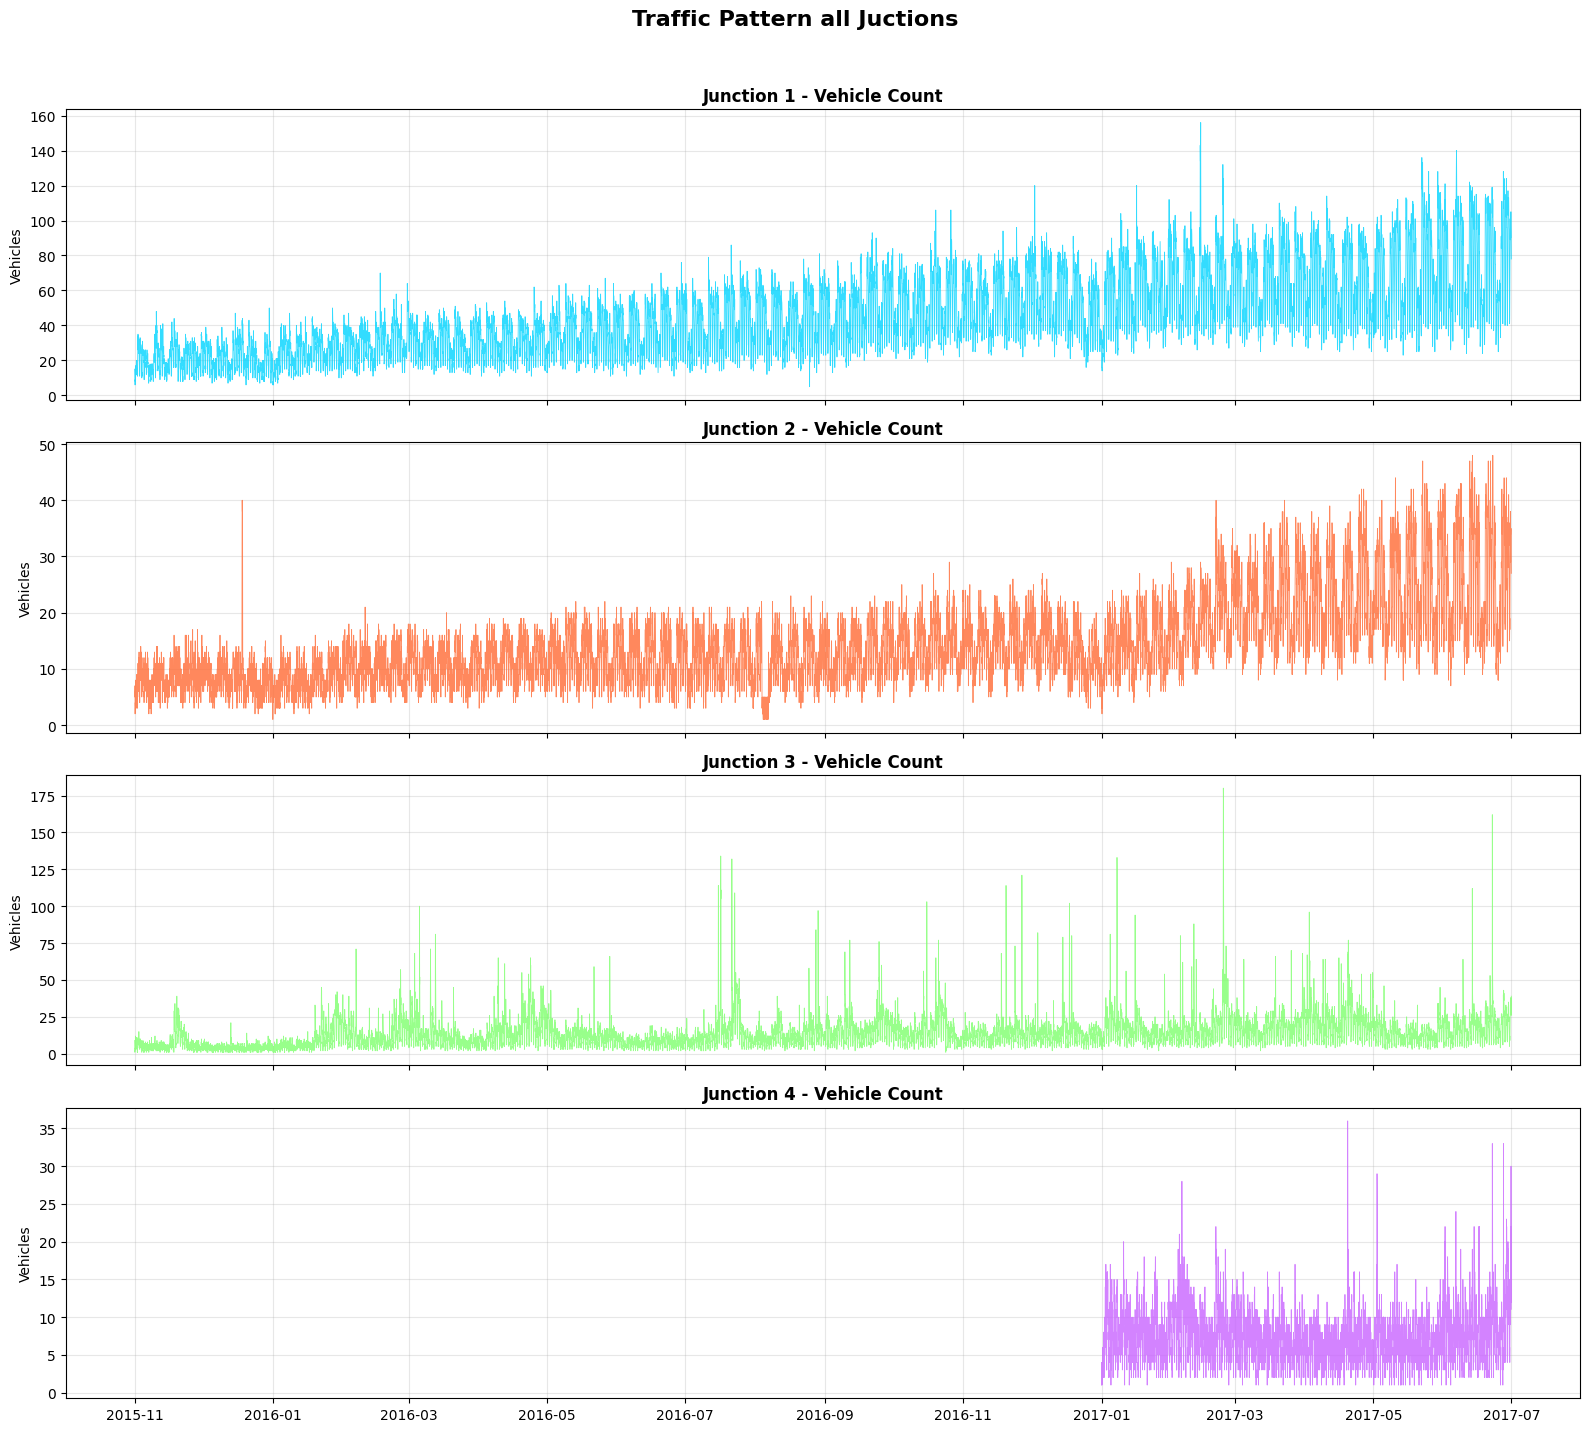

In [35]:
fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)
colors = ['#00d4ff', '#ff6b35', '#7fff6e', '#c864ff']

for i, junction in enumerate([1, 2, 3, 4]):
    jdf = tp[tp['Junction'] == junction] #junction dataframe = jdf
    axes[i].plot(jdf['DateTime'], jdf['Vehicles'], color=colors[i], linewidth=0.6, alpha=0.8)
    axes[i].set_title(f'Junction {junction} - Vehicle Count', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Vehicles')
    axes[i].grid(alpha=0.3)

plt.suptitle('Traffic Pattern all Juctions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/02_traffic_overview.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# Extract time components for analysis
tp['DateTime'] = pd.to_datetime(tp['DateTime'], errors='coerce')
tp['hour'] = tp['DateTime'].dt.hour
tp['weekday'] = tp['DateTime'].dt.day_name()
tp['month']   = tp['DateTime'].dt.month_name()

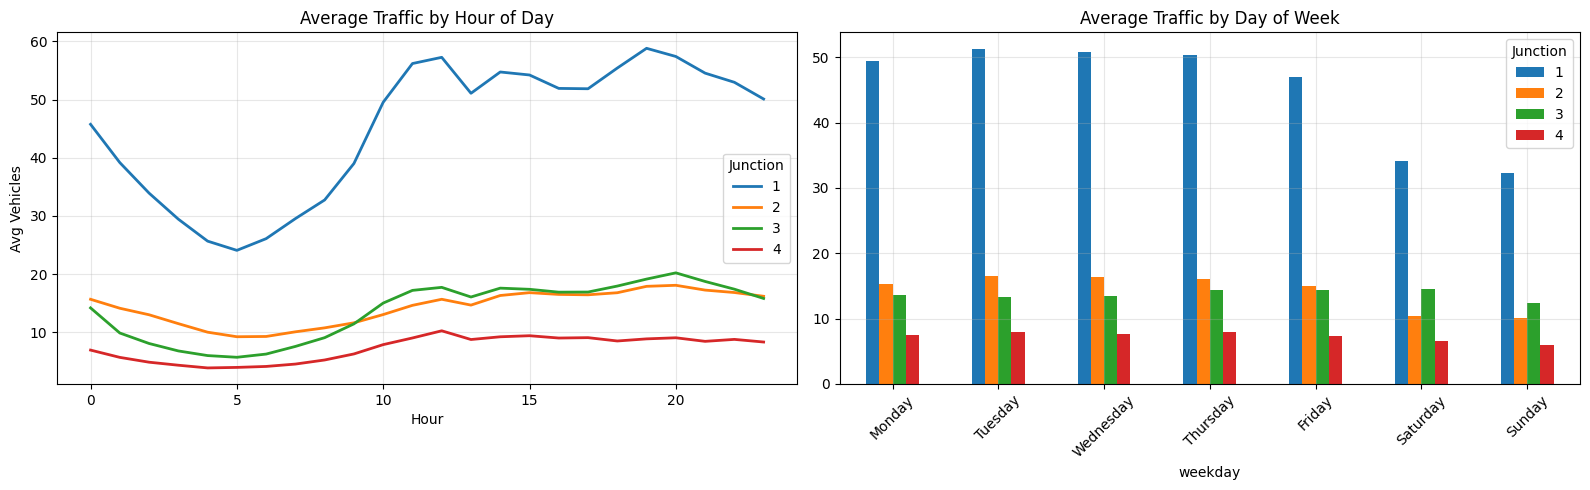

In [31]:
# ── Hourly Average Traffic ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = ['#00d4ff', '#ff6b35', '#7fff6e', '#c864ff']
hourly = tp.groupby(['Junction', 'hour'])['Vehicles'].mean().unstack(level=0)
hourly.plot(ax=axes[0], linewidth=2)
axes[0].set_title('Average Traffic by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Avg Vehicles')
axes[0].grid(alpha=0.3)
# ── Day of Week Pattern ──────────────────────────
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekly = tp.groupby(['Junction', 'weekday'])['Vehicles'].mean().unstack(level=0)
weekly.reindex(day_order).plot(ax=axes[1], kind='bar')
axes[1].set_title('Average Traffic by Day of Week')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/03_hourly_weekly_patterns.png', dpi=150)
plt.show()

Junction 1: 157 outliers detected
Junction 2: 831 outliers detected
Junction 3: 473 outliers detected
Junction 4: 97 outliers detected


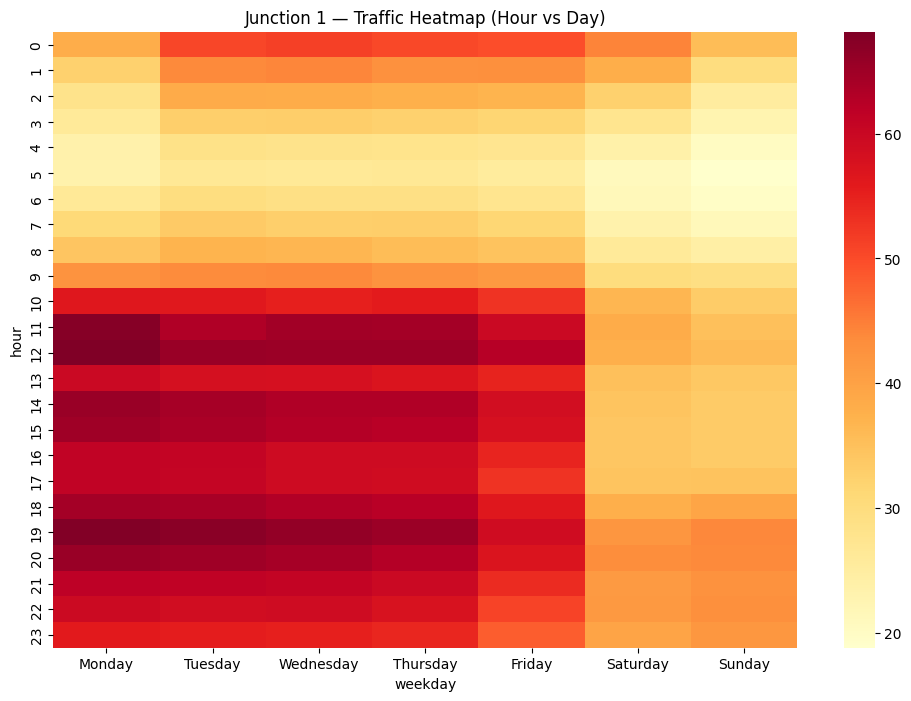

In [26]:
# ── Outlier detection using IQR method ──────────
for j in [1, 2, 3, 4]:
    jdf = tp[tp['Junction'] == j]['Vehicles']
    Q1 = jdf.quantile(0.25)
    Q3 = jdf.quantile(0.75)
    IQR = Q3 - Q1
    outliers = jdf[(jdf < Q1 - 1.5*IQR) | (jdf > Q3 + 1.5*IQR)]
    print(f"Junction {j}: {len(outliers)} outliers detected")

# ── Heatmap: Avg traffic per hour × weekday ──────
import seaborn as sns

j1_df = tp[tp['Junction'] == 1]
pivot = j1_df.pivot_table(
    values='Vehicles', index='hour', columns='weekday', aggfunc='mean'
)[day_order]

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, cmap='YlOrRd', annot=False, fmt='.0f')
plt.title('Junction 1 — Traffic Heatmap (Hour vs Day)')
plt.savefig('../reports/figures/04_heatmap_junction1.png', dpi=150)
plt.show()

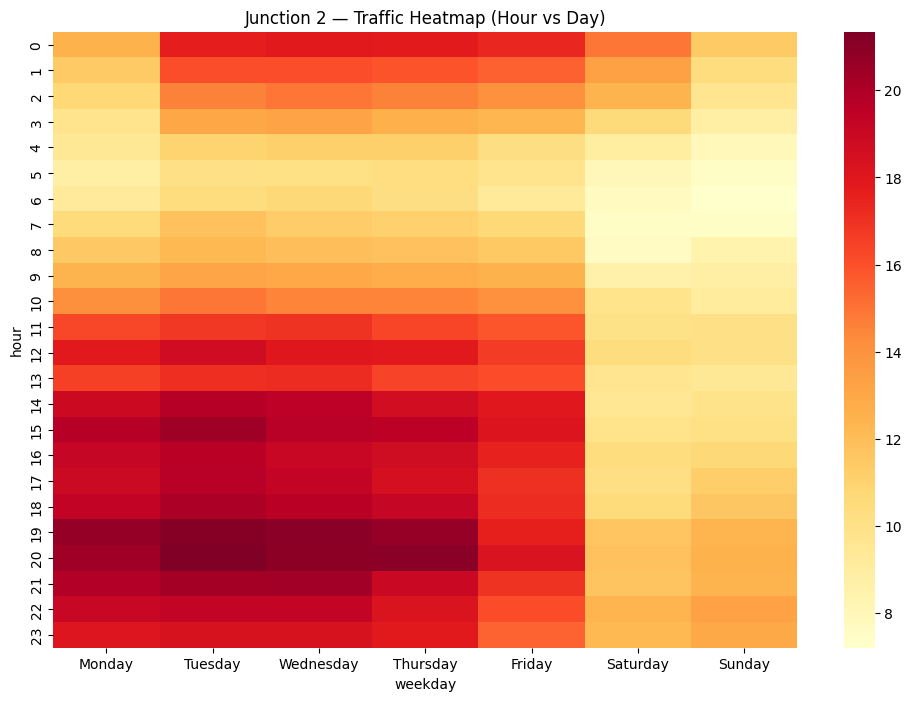

In [28]:
j2_df = tp[tp['Junction'] == 2]
pivot = j2_df.pivot_table(
    values='Vehicles', index='hour', columns='weekday', aggfunc='mean'
)[day_order]

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, cmap='YlOrRd', annot=False, fmt='.0f')
plt.title('Junction 2 — Traffic Heatmap (Hour vs Day)')
plt.savefig('../reports/figures/05_heatmap_junction2.png', dpi=150)
plt.show()

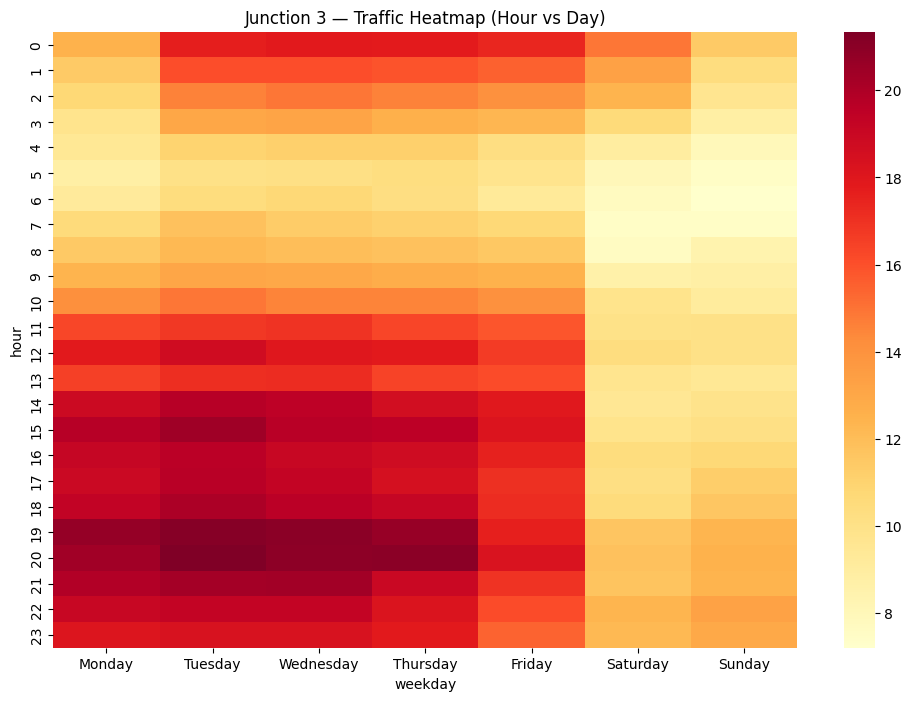

In [29]:
j3_df = tp[tp['Junction'] == 2]
pivot = j3_df.pivot_table(
    values='Vehicles', index='hour', columns='weekday', aggfunc='mean'
)[day_order]

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, cmap='YlOrRd', annot=False, fmt='.0f')
plt.title('Junction 3 — Traffic Heatmap (Hour vs Day)')
plt.savefig('../reports/figures/06_heatmap_junction3.png', dpi=150)
plt.show()

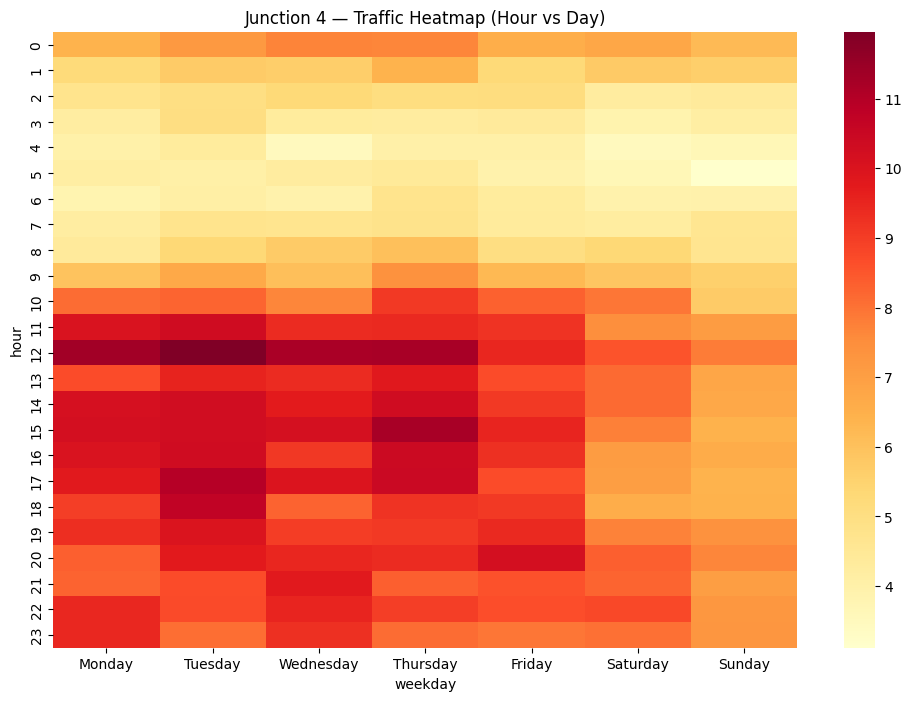

In [30]:
j4_df = tp[tp['Junction'] == 4]
pivot = j4_df.pivot_table(
    values='Vehicles', index='hour', columns='weekday', aggfunc='mean'
)[day_order]

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, cmap='YlOrRd', annot=False, fmt='.0f')
plt.title('Junction 4 — Traffic Heatmap (Hour vs Day)')
plt.savefig('../reports/figures/07_heatmap_junction4.png', dpi=150)
plt.show()